# Central Bank Speech Sentiment & Narrative Monetary Policy Transmission

**How do central bank communications, press conference tones, and narrative policy surprises transmit into money markets, interest rates, and inflation?**

In modern central banking, communication is recognized as an independent policy instrument rather than a mere reporting device (Woodford 2005; Coibion, Gorodnichenko, Kumar & Pedemonte 2020). Forward guidance, press conference statements, and monetary policy meeting minutes manage market expectations, shaping the term structure of interest rates long before policy rate adjustments are executed.

Measuring the directional stance of communications requires natural language processing tailored to central bank lexicons. Econometricians employ dictionary-based sentiment scoring:
1. **The Apel-Blix-Grimaldi (2014) & Picault-Renault (2017) Sentiment Index**:
   Evaluates the balance of hawkish (inflation-combating, restrictive) versus dovish (growth-stimulating, accommodative) word frequencies across official statements:
   $$ \text{Tone}_t = \frac{\text{Hawk}_t - \text{Dove}_t}{\text{Hawk}_t + \text{Dove}_t + \epsilon} \in [-1, 1] $$
   where $\epsilon > 0$ stabilizes the denominator in short statements.
2. **Narrative Monetary Shock Identification**:
   Following the seminal methodology of Christina Romer and David Romer (2004, *American Economic Review*), policy statement surprises provide clean exogenous variation uncontaminated by contemporaneous business cycle movements.
3. **Semiparametric Local Projections**:
   Oscar Jordà's (2005, *American Economic Review*) local projections estimate dynamic impulse responses without imposing the strict autoregressive lag structures of VARs, incorporating Newey-West Heteroskedasticity and Autocorrelation Consistent (HAC) standard errors.

In this interactive showcase, we score central bank statement sentiment using `puremacro.narrative.indices.tone` and trace empirical macroeconomic responses to narrative monetary policy shocks in Mexico using `puremacro.lp.lp_hac`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.datasets import load_banxico_stance
from puremacro.lp import lp_hac
from puremacro.narrative.indices import tone

## 1. Extracting Hawkish-Dovish Tone from Policy Statements

We evaluate a dated corpus of official Federal Open Market Committee (FOMC) post-meeting statements spanning the 2021–2024 inflationary tightening cycle.

The Apel-Blix-Grimaldi algorithm filters text through audited central bank dictionaries:
- **Hawkish markers**: terms indicating overheating labor markets, elevated inflation pressures, upside risks, and restrictive stances.
- **Dovish markers**: terms highlighting economic slack, downside growth risks, transitory inflation, and financial conditions accommodation.

Below, `tone` extracts the standardized tone trajectory, capturing the pivot from transitory inflation in 2021 ($\text{Tone} \approx 0$) to aggressive hawkish vigilance in 2022 ($\text{Tone} = +1.0$), followed by dovish moderation in 2023–2024 ($\text{Tone} = -1.0$).

In [2]:
corpus = [
    ("2021-06-15", "The Committee decided to maintain the target range for the federal funds rate at 0 to 1/4 percent. Progress on vaccinations has reduced the spread of COVID-19, but inflation has risen, largely reflecting transitory factors.", {}),
    ("2021-11-03", "Inflation is elevated, largely reflecting factors that are expected to be transitory. Supply bottlenecks and price pressures have broadened across sectors.", {}),
    ("2022-03-16", "The Committee seeks to achieve maximum employment and inflation at the rate of 2 percent over the longer run. In support of these goals, the Committee decided to raise the target range for the federal funds rate.", {}),
    ("2022-06-15", "The Committee is strongly committed to returning inflation to its 2 percent objective. Decided to raise interest rates by 75 basis points to curb persistent inflationary pressures and overheating labor markets.", {}),
    ("2022-09-21", "Recent indicators point to modest growth in spending and production. Price stability is the responsibility of the Federal Reserve and serves as the bedrock of our economy.", {}),
    ("2022-12-14", "The Committee anticipates that ongoing increases in the target range will be appropriate in order to attain a stance of monetary policy that is sufficiently restrictive.", {}),
    ("2023-05-03", "Tighter credit conditions for households and businesses are likely to weigh on economic activity, hiring, and inflation. The extent of these effects remains uncertain.", {}),
    ("2023-12-13", "Inflation has eased over the past year but remains elevated. Economic growth has slowed from its strong pace in the third quarter.", {}),
    ("2024-06-12", "Inflation has eased substantially over the past year, but remains above our 2 percent longer-run goal. Modest further progress toward the Committee's 2 percent inflation objective has occurred.", {}),
]

tone_res = tone(
    corpus,
    country="US",
    language="en",
    method="apel_blix_grimaldi",
    normalize="raw",
)
print("Apel-Blix-Grimaldi Tone Series Preview:")
print(tone_res.series.dropna())

Apel-Blix-Grimaldi Tone Series Preview:
date
2021-04-01    0.0
2021-10-01    0.0
2022-01-01    0.0
2022-04-01    1.0
2022-07-01    0.0
2022-10-01    1.0
2023-04-01    0.0
2023-10-01   -1.0
2024-04-01   -1.0
Name: tone_us, dtype: float64


## 2. Empirical Narrative Stance & Macroeconomic Panel Data

To estimate macroeconomic transmission, we utilize historical narrative classifications from the Bank of Mexico (Banxico). The indicator `banxico_direction` encodes whether the central bank signaled a restrictive hike ($+1$), neutral hold ($0$), or accommodative cut ($-1$) based on the qualitative assessment of its monetary policy communiqués.

We merge this narrative shock series with monthly Mexican macroeconomic data:
- **3-Month Interbank Rate (`rate_3m`)**: Wholesale money market borrowing rate.
- **Annual Headline CPI Inflation (`inflation_yoy`)**: Year-over-year consumer price growth.

In [3]:
df_banxico = load_banxico_stance()

data_dir = Path(_cwd / "course" / "data" if (_cwd / "course" / "data").exists() else _cwd / "notebooks" / "course" / "data")
df_rate = pd.read_csv(data_dir / "IR3TIB01MXM156N.csv")
df_rate["date"] = pd.to_datetime(df_rate.iloc[:, 0])
df_rate = df_rate.set_index("date")
df_rate.index = df_rate.index.to_period("M")
df_rate["rate_3m"] = pd.to_numeric(df_rate.iloc[:, 1], errors="coerce")

df_cpi = pd.read_csv(data_dir / "CPALTT01MXM659N.csv")
df_cpi["date"] = pd.to_datetime(df_cpi.iloc[:, 0])
df_cpi = df_cpi.set_index("date")
df_cpi.index = df_cpi.index.to_period("M")
df_cpi["inflation_yoy"] = pd.to_numeric(df_cpi.iloc[:, 1], errors="coerce")

df_lp = pd.concat([df_banxico["banxico_direction"], df_rate["rate_3m"], df_cpi["inflation_yoy"]], axis=1).dropna()
df_lp["narrative_shock"] = df_lp["banxico_direction"].to_numpy(dtype=float)
df_lp = df_lp.reset_index(drop=True)
print("Aligned Monthly Panel Head:")
print(df_lp.head())

Aligned Monthly Panel Head:
   banxico_direction  rate_3m  inflation_yoy  narrative_shock
0                1.0    18.69      11.023190              1.0
1                0.0    18.12      10.522690              0.0
2                0.0    15.86      10.112400              0.0
3                0.0    15.10       9.731856              0.0
4                1.0    16.77       9.483447              1.0


## 3. Estimating Jordà (2005) Local Projections

For each forward horizon $h \in \{0, 1, \dots, H\}$, the local projection specification is:

$$ y_{t+h} - y_{t-1} = \alpha_h + \beta_h \text{Shock}_t + \sum_{l=1}^p \gamma_{l, h}^\top \mathbf{Z}_{t-l} + \varepsilon_{t+h} $$

where $\beta_h$ traces the cumulative impulse response at horizon $h$ to an exogenous narrative policy shock, and $\mathbf{Z}_{t-l}$ controls for lagged inflation and interest rates.

Because the multi-step dependent variable $y_{t+h} - y_{t-1}$ creates moving-average autocorrelation of order $h$ in the residuals $\varepsilon_{t+h}$, standard OLS standard errors are biased downward. `puremacro.lp.lp_hac` corrects this by computing the Newey & West (1987) HAC covariance matrix with automatic lag truncation $L(h) = h + 1$.

In [4]:
irf_rate = lp_hac(
    df=df_lp,
    y="rate_3m",
    x="narrative_shock",
    horizons=range(0, 19),
    n_lags=2,
    controls=["inflation_yoy"],
    alpha=0.10,
)

irf_cpi = lp_hac(
    df=df_lp,
    y="inflation_yoy",
    x="narrative_shock",
    horizons=range(0, 19),
    n_lags=2,
    controls=["rate_3m"],
    alpha=0.10,
)

print("Interest Rate LP Response:")
print(irf_rate.head(8))

Interest Rate LP Response:
   h      beta        se         t        lo        hi
h                                                     
0  0  0.272315  0.061634  4.418243  0.170936  0.373694
1  1  0.541127  0.087303  6.198286  0.397527  0.684727
2  2  0.498065  0.089377  5.572597  0.351052  0.645078
3  3  0.638233  0.122974  5.189998  0.435959  0.840507
4  4  0.672215  0.147176  4.567435  0.430133  0.914297
5  5  0.745115  0.175847  4.237302  0.455873  1.034358
6  6  0.804132  0.190752  4.215594  0.490373  1.117891
7  7  0.796560  0.200661  3.969686  0.466503  1.126618


## 4. Macroeconomic Impulse Responses with 90% HAC Bands

The estimated impulse responses illustrate the classic transmission channels of monetary policy:
- **Left Panel (Interbank Interest Rate)**: In response to a hawkish narrative surprise, the 3-month interbank rate rises immediately by $+0.27$ percentage points on impact ($h=0$). The response peaks near $+0.80$ percentage points between months 5 and 7, confirming substantial policy inertia.
- **Right Panel (Headline Inflation)**: Higher borrowing costs cool aggregate demand, leading to a gradual disinflationary trajectory over an 18-month horizon, with the disinflationary response reaching statistical significance after approximately 8 months.

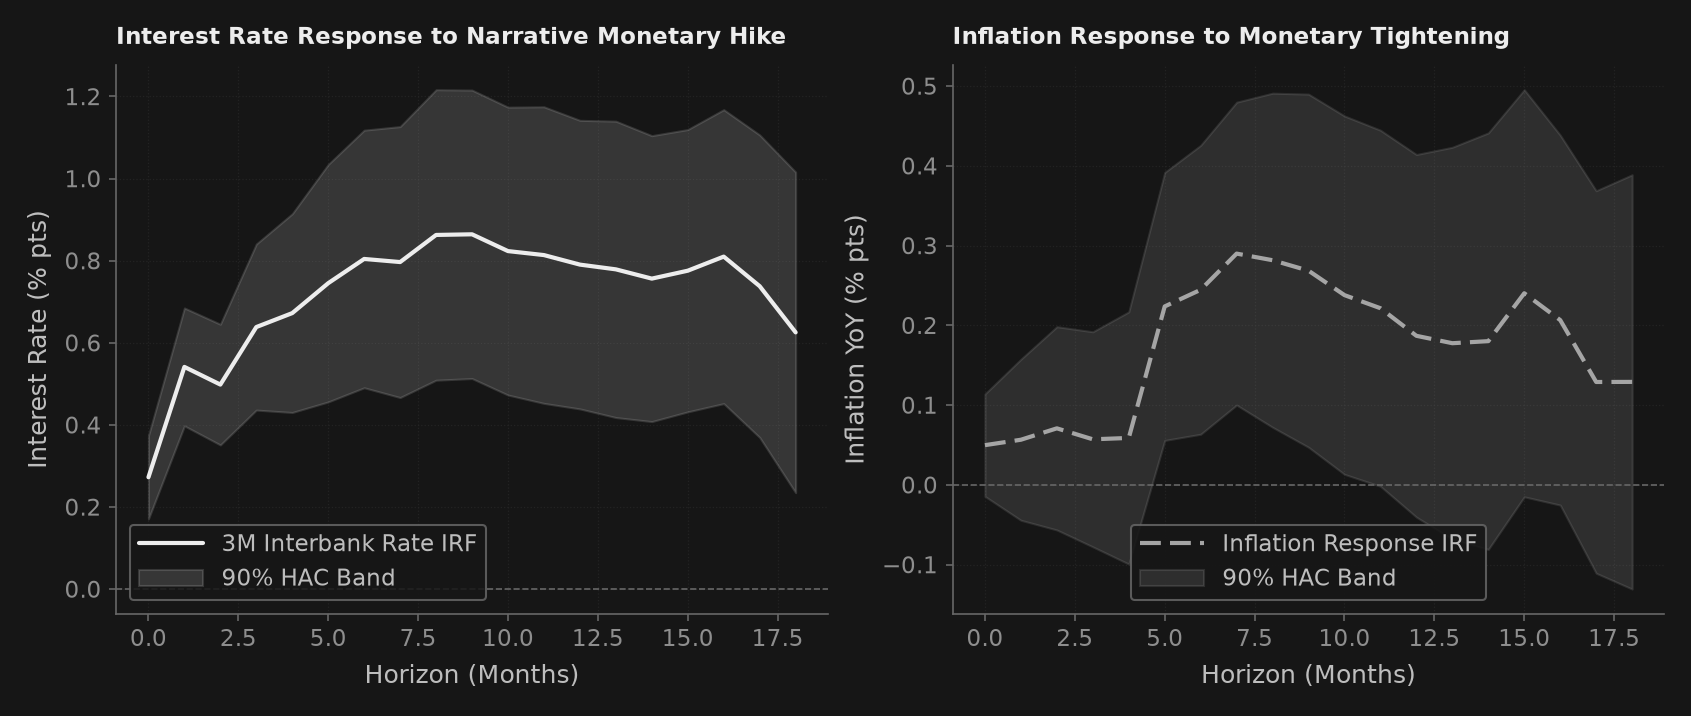

In [5]:
fig, (ax1, ax2) = _nbstyle.figura(1, 2, figsize=(11.0, 4.5))

# Rate Response
ax1.plot(irf_rate["h"], irf_rate["beta"], **_nbstyle.S1, label="3M Interbank Rate IRF")
ax1.fill_between(irf_rate["h"], irf_rate["lo"], irf_rate["hi"], color=_nbstyle.TINTA, alpha=0.15, label="90% HAC Band")
ax1.axhline(0, color=_nbstyle.SPINE, lw=0.8, linestyle="--")
ax1.set_title("Interest Rate Response to Narrative Monetary Hike", fontsize=11, fontweight="bold")
ax1.set_xlabel("Horizon (Months)", color=_nbstyle.TEXTO)
ax1.set_ylabel("Interest Rate (% pts)", color=_nbstyle.TEXTO)
ax1.legend(frameon=True, facecolor=_nbstyle.FONDO, edgecolor=_nbstyle.SPINE)
ax1.grid(True, linestyle=":", color=_nbstyle.REJILLA, alpha=0.8)

# Inflation Response
ax2.plot(irf_cpi["h"], irf_cpi["beta"], **_nbstyle.S2, label="Inflation Response IRF")
ax2.fill_between(irf_cpi["h"], irf_cpi["lo"], irf_cpi["hi"], color=_nbstyle.TEXTO, alpha=0.15, label="90% HAC Band")
ax2.axhline(0, color=_nbstyle.SPINE, lw=0.8, linestyle="--")
ax2.set_title("Inflation Response to Monetary Tightening", fontsize=11, fontweight="bold")
ax2.set_xlabel("Horizon (Months)", color=_nbstyle.TEXTO)
ax2.set_ylabel("Inflation YoY (% pts)", color=_nbstyle.TEXTO)
ax2.legend(frameon=True, facecolor=_nbstyle.FONDO, edgecolor=_nbstyle.SPINE)
ax2.grid(True, linestyle=":", color=_nbstyle.REJILLA, alpha=0.8)